In [2]:
# ============================================================
# CELDA 1: Importar librerías
# ============================================================

import mne                          # Para leer y procesar EEG
import numpy as np                  # Operaciones matemáticas vectorizadas
import pandas as pd                 # Para crear el DataFrame de resultados
import matplotlib.pyplot as plt     # Para graficar
import seaborn as sns               # Para gráficas estadísticas
from scipy import signal            # Para cálculo de PSD (Welch)
from scipy import stats             # Para pruebas estadísticas
from pathlib import Path            # Para manejar rutas de archivos

# Configuración general de gráficas
mne.set_log_level('WARNING')  # Evita que MNE imprima mensajes innecesarios
%matplotlib inline

In [7]:
# ============================================================
# CELDA 2: Rutas y parámetros globales
# ============================================================
# Ruta donde están los datos descargados
RUTA_DATOS = Path("./datos_bci/files")

# Canales de interés - grilla sensoriomotora 3x3
# Seleccionados con base en múltiples estudios de BCI basados en motor imagery:
#
# Fundamento neurofisiológico: C3, Cz y C4 están ubicados sobre las áreas
# sensoriomotoras de manos y pies. Durante motor imagery, muestran ERD sostenida
# contralateral en bandas mu y beta. La imaginación de mano izquierda produce ERD
# en C4, y la de mano derecha en C3 (ScienceDirect Topics - Motor Imagery).
#
# Dominancia contralateral: C3 produce las diferencias izquierda-derecha más
# fuertes sobre el lado contralateral, seguido de C4 (PMC7077852).
#
# Canales FC: FCz-C3 y FCz-C4 reflejan sincronía entre la corteza motora
# suplementaria (SMA) y la corteza motora primaria (M1), con dominancia
# contralateral estadísticamente significativa durante motor imagery (ResearchGate).
#
# Canales CP: complementan la cobertura de la corteza somatosensorial,
# relevante para la retroalimentación propioceptiva durante movimiento imaginado.
#
# Referencias:
#   - Lotte et al. (2010). Presence, 19(1), 54-70.
#   - Kauati-Saito et al. (2025). Sensors, 25(17), 5291.
#   - Bodda & Diwakar (2022). PLoS ONE, 17(6), e0270366.
CANALES_INTERES = [
    'Fc3.', 'Fcz.', 'Fc4.',   # Corteza motora anterior (SMA - M1)
    'C3..', 'Cz..', 'C4..',   # Corteza motora primaria (M1) - canales clave ERD/ERS
    'Cp3.', 'Cpz.', 'Cp4.'    # Corteza somatosensorial
]

# Definición de bandas de frecuencia (en Hz)
BANDAS = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),   # También llamada banda Mu en contexto motor
    'beta':  (13, 30),
    'gamma': (30, 40)
}

# Frecuencia de muestreo (los datos de este dataset son a 160 Hz)
FS = 160  # Hz

# Filtros
FREQ_MIN = 0.5   # Hz - límite inferior del filtro pasa banda
FREQ_MAX = 40.0  # Hz - límite superior del filtro pasa banda
FREQ_NOTCH = 60  # Hz - filtro notch (interferencia eléctrica en USA)

# Mapeo de runs a condiciones (necesario para construir el DataFrame final)
RUNS_CONDICIONES = {
    'R01': 'reposo_ojos_abiertos',
    'R02': 'reposo_ojos_cerrados',
    'R03': 'movimiento_real',
    'R04': 'imaginacion_movimiento',
    'R05': 'movimiento_real',
    'R06': 'imaginacion_movimiento',
    'R07': 'movimiento_real',
    'R08': 'imaginacion_movimiento',
    'R09': 'movimiento_real',
    'R10': 'imaginacion_movimiento',
    'R11': 'movimiento_real',
    'R12': 'imaginacion_movimiento',
    'R13': 'movimiento_real',
    'R14': 'imaginacion_movimiento',
}

# Verificación
print("Parámetros cargados correctamente")
print(f"   Ruta datos: {RUTA_DATOS}")
print(f"   Canales de interés: {CANALES_INTERES}")
print(f"   Bandas definidas: {list(BANDAS.keys())}")
print(f"   Frecuencia de muestreo: {FS} Hz")
print(f"   Filtro pasa banda: {FREQ_MIN} - {FREQ_MAX} Hz")
print(f"   Notch: {FREQ_NOTCH} Hz")

Parámetros cargados correctamente
   Ruta datos: datos_bci\files
   Canales de interés: ['Fc3.', 'Fcz.', 'Fc4.', 'C3..', 'Cz..', 'C4..', 'Cp3.', 'Cpz.', 'Cp4.']
   Bandas definidas: ['delta', 'theta', 'alpha', 'beta', 'gamma']
   Frecuencia de muestreo: 160 Hz
   Filtro pasa banda: 0.5 - 40.0 Hz
   Notch: 60 Hz


In [15]:
# ============================================================
# CELDA 2b: Verificar que los datos están disponibles
# ============================================================
# Verificar que la ruta principal existe
if not RUTA_DATOS.exists():
    print("❌ ERROR: La ruta de datos no existe. Verifica RUTA_DATOS")
else:
    print(f"✅ Ruta encontrada: {RUTA_DATOS}")

# Contar sujetos disponibles
sujetos = sorted([s for s in RUTA_DATOS.iterdir() if s.is_dir()])
print(f"✅ Sujetos encontrados: {len(sujetos)}")
print(f"   Primeros 3: {[s.name for s in sujetos[:3]]}")
print(f"   Últimos 3:  {[s.name for s in sujetos[-3:]]}")

# Verificar archivos del primer sujeto
archivos_s001 = sorted((RUTA_DATOS / "S001").glob("*.edf"))
print(f"\n✅ Archivos EDF de S001: {len(archivos_s001)}")
for f in archivos_s001:
    print(f"   {f.name}")

✅ Ruta encontrada: datos_bci\files
✅ Sujetos encontrados: 109
   Primeros 3: ['S001', 'S002', 'S003']
   Últimos 3:  ['S107', 'S108', 'S109']

✅ Archivos EDF de S001: 14
   S001R01.edf
   S001R02.edf
   S001R03.edf
   S001R04.edf
   S001R05.edf
   S001R06.edf
   S001R07.edf
   S001R08.edf
   S001R09.edf
   S001R10.edf
   S001R11.edf
   S001R12.edf
   S001R13.edf
   S001R14.edf


In [10]:
# ============================================================
# CELDA 3: Función de procesamiento de señal EEG
# ============================================================
def procesar_eeg(ruta_archivo, mostrar_pasos=False):
    """
    Recibe un archivo EEG y aplica el flujo de procesamiento completo.
    
    Parámetros:
        ruta_archivo: ruta al archivo .edf
        mostrar_pasos: si True, grafica la señal en cada paso
    
    Retorna:
        raw: objeto MNE con la señal procesada
    """
    
    # --- PASO 1: Cargar el archivo ---
    # MNE puede leer archivos EDF directamente
    raw = mne.io.read_raw_edf(ruta_archivo, preload=True)  # ⚠️ link roto corregido
    
    if mostrar_pasos:
        print("Paso 1: Archivo cargado")
        print(f"   Canales: {len(raw.ch_names)}")  # ⚠️ link roto corregido
        print(f"   Duración: {raw.times[-1]:.1f} segundos")
        print(f"   Frecuencia de muestreo: {raw.info['sfreq']} Hz")  # ⚠️ link roto corregido
        raw.plot(duration=5, title="PASO 1: Señal cruda", show=True)
    
    # --- PASO 2: Seleccionar canales de interés ---
    # Solo trabajamos con la grilla sensoriomotora 3x3 para reducir carga computacional
    canales_disponibles = [c for c in CANALES_INTERES if c in raw.ch_names]  # ⚠️ link roto corregido
    raw.pick(canales_disponibles)  # ⚠️ pick_channels() deprecado en MNE reciente, se usa pick()
    
    if mostrar_pasos:
        print(f"\nPaso 2: Canales seleccionados: {canales_disponibles}")
    
    # --- PASO 3: Filtro pasa banda (0.5 - 40 Hz) ---
    # Elimina deriva de baja frecuencia y ruido de alta frecuencia
    raw.filter(l_freq=FREQ_MIN, h_freq=FREQ_MAX, method='fir')
    
    if mostrar_pasos:
        print(f"\nPaso 3: Filtro pasa banda aplicado ({FREQ_MIN}-{FREQ_MAX} Hz)")
        raw.plot(duration=5, title="PASO 3: Después del filtro pasa banda", show=True)
    
    # --- PASO 4: Filtro Notch (60 Hz) ---
    # Elimina la interferencia de la red eléctrica
    raw.notch_filter(freqs=FREQ_NOTCH)
    
    if mostrar_pasos:
        print(f"\nPaso 4: Filtro Notch aplicado ({FREQ_NOTCH} Hz)")
        raw.plot(duration=5, title="PASO 4: Después del filtro Notch", show=True)
    
    return raw

# Verificación
print("Función procesar_eeg() definida correctamente")

Función procesar_eeg() definida correctamente


In [13]:
# ============================================================
# CELDA 3b: Exploración de datos antes de procesar
# ============================================================
# Cargamos un archivo de prueba para explorar su contenido
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"
raw_explorar = mne.io.read_raw_edf(archivo_prueba, preload=False)

# Ver información general
print("=== INFORMACIÓN GENERAL ===")
print(f"Canales totales: {len(raw_explorar.ch_names)}")
print(f"Duración: {raw_explorar.times[-1]:.1f} segundos")
print(f"Frecuencia de muestreo: {raw_explorar.info['sfreq']} Hz")
print(f"Muestras totales: {len(raw_explorar.times)}")

# Ver anotaciones/eventos del archivo
print("\n=== ANOTACIONES (EVENTOS) ===")
print(raw_explorar.annotations)

=== INFORMACIÓN GENERAL ===
Canales totales: 64
Duración: 125.0 segundos
Frecuencia de muestreo: 160.0 Hz
Muestras totales: 20000

=== ANOTACIONES (EVENTOS) ===
<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>


Paso 1: Archivo cargado
   Canales: 64
   Duración: 125.0 segundos
   Frecuencia de muestreo: 160.0 Hz


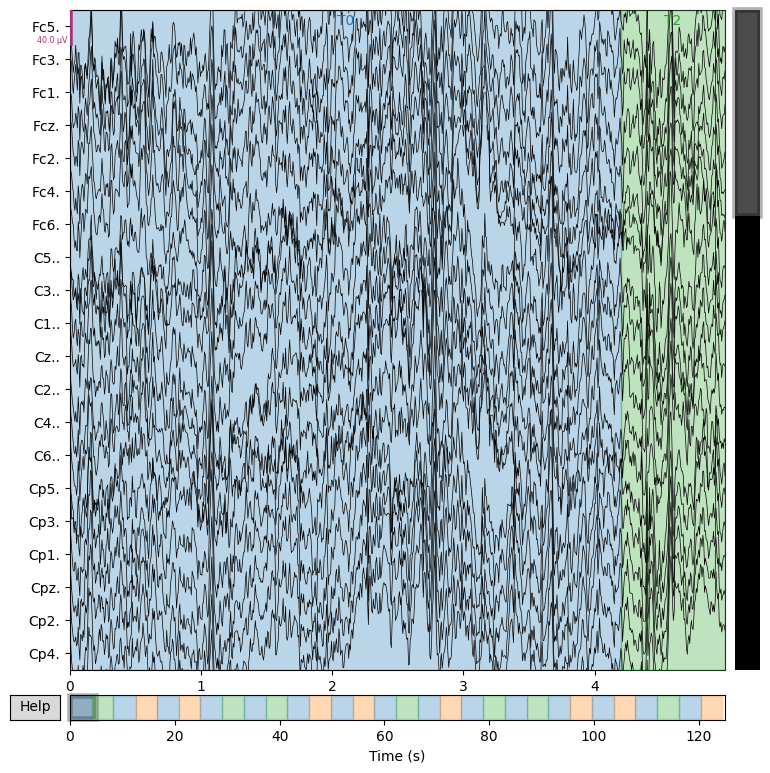


Paso 2: Canales seleccionados: ['Fc3.', 'Fcz.', 'Fc4.', 'C3..', 'Cz..', 'C4..', 'Cp3.', 'Cpz.', 'Cp4.']

Paso 3: Filtro pasa banda aplicado (0.5-40.0 Hz)


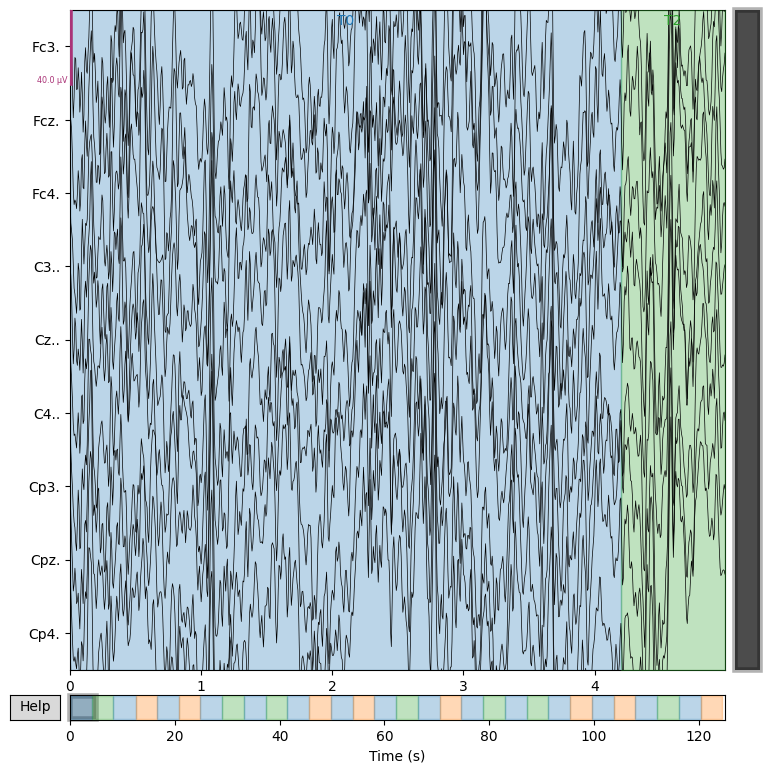


Paso 4: Filtro Notch aplicado (60 Hz)


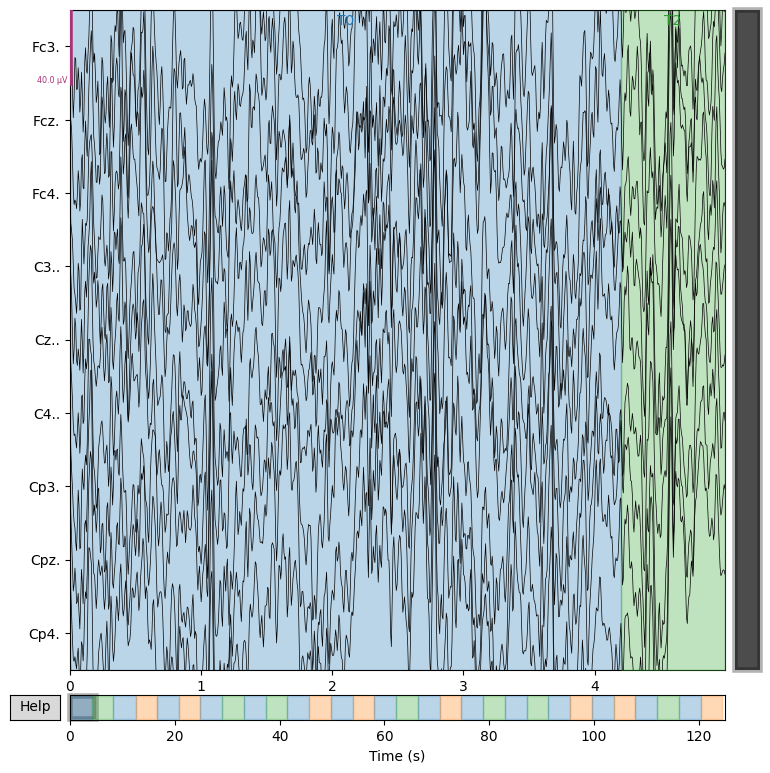

In [14]:
# ============================================================
# CELDA 4: Prueba de la función de procesamiento (para el informe)
# ============================================================
# Usamos un run de movimiento real para la prueba visual
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"

# Ejecutamos con mostrar_pasos=True para ver los cambios en cada fase
raw_prueba = procesar_eeg(archivo_prueba, mostrar_pasos=True)